# Convolutional Neural Network (CNN) - PyTorch

Using device: cpu
PyTorch: 2.10.0+cpu
Epoch 1/15 - loss: 1.9825 - accuracy: 0.4224 - val_loss: 1.2957 - val_accuracy: 0.7056
Epoch 2/15 - loss: 0.7361 - accuracy: 0.8128 - val_loss: 0.3700 - val_accuracy: 0.8917
Epoch 3/15 - loss: 0.3264 - accuracy: 0.8963 - val_loss: 0.2314 - val_accuracy: 0.9139
Epoch 4/15 - loss: 0.2273 - accuracy: 0.9339 - val_loss: 0.1677 - val_accuracy: 0.9556
Epoch 5/15 - loss: 0.1695 - accuracy: 0.9562 - val_loss: 0.1405 - val_accuracy: 0.9583
Epoch 6/15 - loss: 0.1313 - accuracy: 0.9589 - val_loss: 0.1180 - val_accuracy: 0.9694
Epoch 7/15 - loss: 0.1217 - accuracy: 0.9638 - val_loss: 0.1238 - val_accuracy: 0.9750
Epoch 8/15 - loss: 0.0987 - accuracy: 0.9715 - val_loss: 0.1123 - val_accuracy: 0.9667
Epoch 9/15 - loss: 0.0910 - accuracy: 0.9749 - val_loss: 0.1050 - val_accuracy: 0.9694
Epoch 10/15 - loss: 0.0780 - accuracy: 0.9826 - val_loss: 0.0868 - val_accuracy: 0.9806
Epoch 11/15 - loss: 0.0660 - accuracy: 0.9791 - val_loss: 0.0793 - val_accuracy: 0.9778
Epo

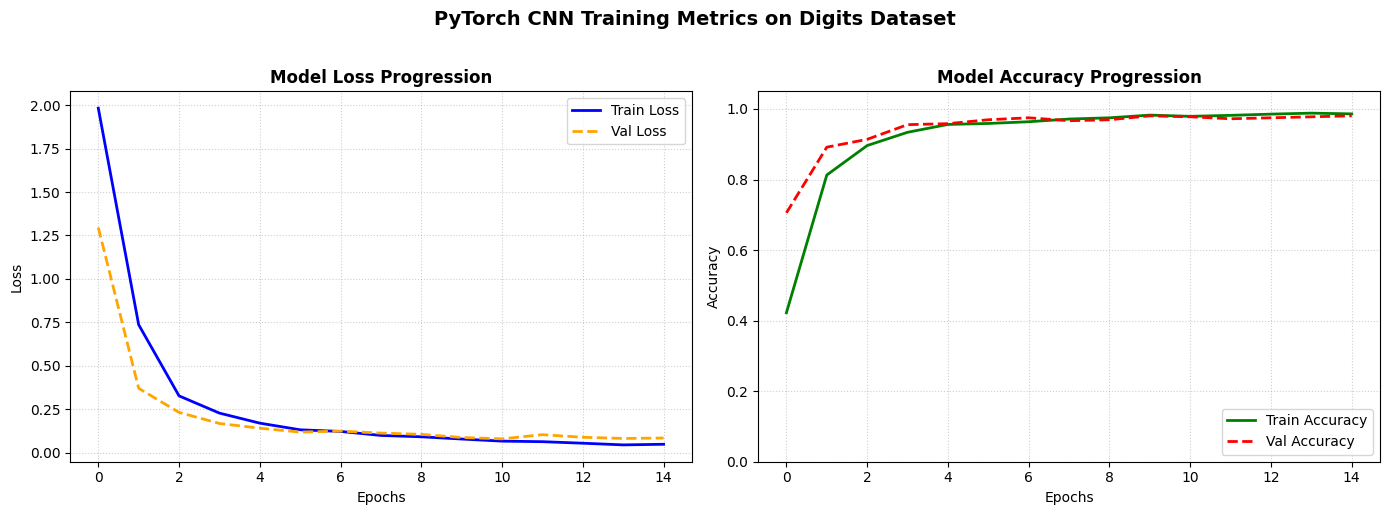

In [3]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ── 0. REPRODUCIBILITY & SETUP ─────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")

# ── 1. DATA PREPARATION ───────────────────────────────────────────────────────
digits = load_digits()

# PyTorch expects (Batch, Channels, Height, Width)
# Reshape from (N, 8, 8) to (N, 1, 8, 8)
X = (digits.images / 16.0).astype("float32")[:, None, :, :]
y = digits.target.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Convert to PyTorch Tensors and create DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

# Batch size lowered to 32 to match the corrected TF logic
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ── 2. MODEL ARCHITECTURE ─────────────────────────────────────────────────────
class DigitsCNN(nn.Module):
    def __init__(self):
        super(DigitsCNN, self).__init__()
        # Input: 1 x 8 x 8 -> Conv -> 16 x 8 x 8 (due to padding=1)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        # MaxPool -> 16 x 4 x 4
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Conv -> 32 x 4 x 4
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.3)
        # 32 channels * 4 * 4 spatial dimensions = 512 flattened features
        self.fc = nn.Linear(32 * 4 * 4, 10)
        # Note: No Softmax here, nn.CrossEntropyLoss handles it

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = DigitsCNN().to(device)

# ── 3. TRAINING PIPELINE ──────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-3)

epochs = 15
history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    history["loss"].append(running_loss / total)
    history["accuracy"].append(correct / total)

    # --- Validation Phase ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    history["val_loss"].append(val_loss / val_total)
    history["val_accuracy"].append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"loss: {history['loss'][-1]:.4f} - accuracy: {history['accuracy'][-1]:.4f} - "
          f"val_loss: {history['val_loss'][-1]:.4f} - val_accuracy: {history['val_accuracy'][-1]:.4f}")

# ── 4. VISUALIZATION PIPELINE ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax1.plot(history["loss"], label="Train Loss", color="blue", lw=2)
ax1.plot(history["val_loss"], label="Val Loss", color="orange", lw=2, linestyle="--")
ax1.set_title("Model Loss Progression", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend(frameon=True)
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Accuracy curves
ax2.plot(history["accuracy"], label="Train Accuracy", color="green", lw=2)
ax2.plot(history["val_accuracy"], label="Val Accuracy", color="red", lw=2, linestyle="--")
ax2.set_title("Model Accuracy Progression", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.05)
ax2.legend(frameon=True, loc="lower right")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("PyTorch CNN Training Metrics on Digits Dataset", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()